In [1]:
!pip install medmnist

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.8/12.3 MB 10.1 MB/s eta 0:00:02
   ------------- -------------------------- 4.2/12.3 MB 10.5 MB/s eta 0:00:01
   --------------------- ------------------ 6.6/12.3 MB 10.6 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.3 MB 10.8 MB/s eta 0:00:01
   ------------------------------------- -- 11.5/12.3 MB 10.9 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.3 MB 10.6 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 9.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   --------- ------------------------------ 


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

import medmnist
from medmnist import INFO, Evaluator

In [57]:
print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")

MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/


# We work on the 2D dataset with size 28x28

In [58]:
data_flag = 'bloodmnist'
download = True
BATCH_SIZE = 128

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

## First, we read the MedMNIST data, preprocess them and encapsulate them into dataloader form.

In [59]:
# preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

pil_dataset = DataClass(split='train', download=download)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [60]:
print(train_dataset)
print("===================")
print(test_dataset)

Dataset BloodMNIST of size 28 (bloodmnist)
    Number of datapoints: 11959
    Root location: C:\Users\alexk\.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
    Number of samples: {'train': 11959, 'val': 1712, 'test': 3421}
    Description: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
    Lice

In [44]:
# visualization

train_dataset.montage(length=1)



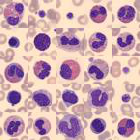

In [45]:

train_dataset.montage(length=5)

In [61]:
#Access a single image / label
image, label = train_dataset[2]  # image is a tensor , label is an  int
print("Shape da imagem:", image.shape)
print("Classe:", label)

# Convert to NumPy array
image_array = image.numpy()
print("Size:", image_array.shape )

#Access a subset of images
img = train_dataset[1][0].numpy   # image
lab = train_dataset[1][1]   # label
start_idx = 10
end_idx = 20  # exclusive
images_array = np.stack([train_dataset[i][0].numpy() for i in range(start_idx, end_idx)])
labels_array = np.array([train_dataset[i][1] for i in range(start_idx, end_idx)])

print("Size:", images_array.shape )
print(labels_array)




Shape da imagem: torch.Size([3, 28, 28])
Classe: [6]
Size: (3, 28, 28)
Size: (10, 3, 28, 28)
[[1]
 [1]
 [6]
 [7]
 [6]
 [3]
 [7]
 [2]
 [6]
 [1]]


DEFINING THE MODEL ❗❗

In [73]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 64, kernel_size = 3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels = 64, out_channels = 128, kernel_size = 3, padding =1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels = 128, out_channels = 256, kernel_size = 3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
    
        self.flatten = nn.Flatten()
        
        self.dense = nn.Linear(256 * 3 * 3, 128)
        self.relu = nn.ReLU()
        self.output = nn.Linear(128, 8)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.relu(self.conv3(x))
        x = self.pool3(x)
        x = self.flatten(x)
        x = self.relu(self.dense(x))
        x = self.output(x)
        return x

SET UP 🤨🤨🤨

In [74]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

TRAINING LOOP 🚨🚨🚨 + VALIDATION NATION 🥶🥶

In [70]:
val_dataset = DataClass(split='val', transform=data_transform, download=download)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=2*BATCH_SIZE, shuffle=True)

AttributeError: 'Tensor' object has no attribute 'DataLoader'

In [75]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for data, labels in train_loader:
        data = data.to(device)
        labels = labels.squeeze().long().to(device)  # important for CrossEntropyLoss

        optimizer.zero_grad()

        outputs = model(data)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    valid_loss = 0.0
    model.eval()
    for data, labels in val_loader:
        data = data.to(device)
        labels = labels.squeeze().long().to(device)
        
        # Forward Pass
        target = model(data)
        # Find the Loss
        loss = criterion(target,labels)
        # Calculate Loss
        valid_loss += loss.item()

    print(f"Epoch {epoch + 1}\t\tTraining Loss: {epoch_loss / len(train_loader):.4f}\t\tValidation Loss: {valid_loss / len(val_loader):.4f}")


Epoch 1		Training Loss: 1.3235		Validation Loss: 0.7955
Epoch 2		Training Loss: 0.7075		Validation Loss: 0.5816
Epoch 3		Training Loss: 0.5956		Validation Loss: 0.6417
Epoch 4		Training Loss: 0.5295		Validation Loss: 0.4948
Epoch 5		Training Loss: 0.4639		Validation Loss: 0.4896
Epoch 6		Training Loss: 0.4138		Validation Loss: 0.3768
Epoch 7		Training Loss: 0.3667		Validation Loss: 0.3694
Epoch 8		Training Loss: 0.3423		Validation Loss: 0.3293
Epoch 9		Training Loss: 0.3199		Validation Loss: 0.3232
Epoch 10		Training Loss: 0.2927		Validation Loss: 0.3521


EVALUATION
🗣️🗣️🗣️🗣️

In [76]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy on test set: {accuracy:.2f}%')

Accuracy on test set: 86.09%
